In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

In [30]:
plt.rcParams.update({
            'font.family': 'arial',
            'font.size': 12,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'svg.fonttype': 'none',
            'font.size': 10,
            'axes.titlesize': 10,
            'axes.labelsize': 8,
            'xtick.labelsize': 8,
            'ytick.labelsize': 8,
            'legend.fontsize': 9,
            'figure.titlesize': 10
        })

In [18]:
PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}


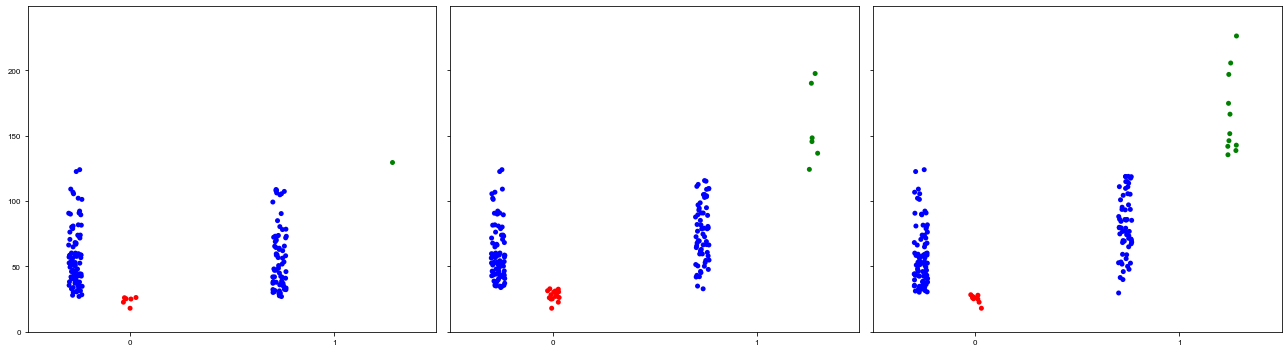

In [59]:
# We need to find the overlapping region for each scenario
# Then color code the dots based on whether they are part of the overlap# Create a new function to calculate overlap percentage and color the dots
def calculate_overlap(data1, data2):
    # Find the common range for overlap
    lower_bound = max(min(data1), min(data2))
    upper_bound = min(max(data1), max(data2))    # Count how many data points are in the overlap range
    overlap_data1 = [x for x in data1 if lower_bound <= x <= upper_bound]
    overlap_data2 = [x for x in data2 if lower_bound <= x <= upper_bound]
    overlap_count = len(overlap_data1) + len(overlap_data2)    # Calculate the percentage of overlap
    total_data_count = len(data1) + len(data2)
    overlap_percentage = (overlap_count / total_data_count) * 100    # Determine the colors for the data points
    colors1 = ['o' if lower_bound <= x <= upper_bound else 't' for x in data1]
    colors2 = ['o' if lower_bound <= x <= upper_bound else 't' for x in data2]    
    return overlap_percentage, colors1, colors2, overlap_data1, overlap_data2# Plot setup

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)# Loop through each scenario to perform tests, calculate overlap, and plot
for i, data2 in enumerate(data2_scenarios):
    # Calculate overlap
    overlap_percentage, colors1, colors2, overlap_data1, overlap_data2 = calculate_overlap(data1, data2)    # Perform Mann-Whitney U test
    u_statistic, p_value = mannwhitneyu(data1, data2)
    # Rank Biserial Correlation
    u = u_statistic
    n1 = len(data1)
    n2 = len(data2)
    rbc = 1 - (2 * u) / (n1 * n2)    # Create combined data and category labels for stripplot
    combined_data = np.concatenate([data1, data2])
    category_labels = np.array(['0']*len(data1) + ['1']*len(data2))    # Color the stripplot points based on overlap
    sns.stripplot(x=category_labels, y=combined_data, hue=np.concatenate([colors1, colors2]),
                  jitter=True, ax=axes[i], palette=['b','r', 'g'], dodge=True)    # Remove the legend created by hue
    axes[i].legend([],[], frameon=False)    # Annotate with statistics and overlap percentage

plt.ylim([0, max(np.concatenate(data2_scenarios).max(), data1.max()) * 1.1])
plt.tight_layout()
plt.show()

In [73]:
# We need to find the overlapping region for each scenario
# Then color code the dots based on whether they are part of the overlap# Create a new function to calculate overlap percentage and color the dots
def calculate_overlap(data1, data2):
    # Find the common range for overlap
    lower_bound = max(min(data1), min(data2))
    upper_bound = min(max(data1), max(data2))    # Count how many data points are in the overlap range
    overlap_data1 = [x for x in data1 if lower_bound <= x <= upper_bound]
    overlap_data2 = [x for x in data2 if lower_bound <= x <= upper_bound]
    overlap_count = len(overlap_data1) + len(overlap_data2)    # Calculate the percentage of overlap
    total_data_count = len(data1) + len(data2)
    overlap_percentage = (overlap_count / total_data_count) * 100    # Determine the colors for the data points
    colors1 = ['overlap' if lower_bound <= x <= upper_bound else 'opposed' for x in data1]
    colors2 = ['overlap' if lower_bound <= x <= upper_bound else 'opposed' for x in data2]    
    return overlap_percentage, colors1, colors2, overlap_data1, overlap_data2# Plot setup


In [80]:
overlap_percentage

88.23529411764706

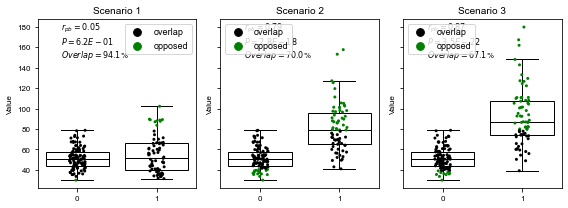

In [97]:
# Fixed data1 distribution
np.random.seed(0)
data1 = np.random.lognormal(mean=np.log(50), sigma=0.2, size=100)

# Define three scenarios for data2 with increasing effect sizes and right-skewness
data2_scenarios = [
    np.random.lognormal(mean=np.log(50), sigma=0.3, size=70),  # Smaller effect size
    np.random.lognormal(mean=np.log(80), sigma=0.3, size=70),  # Medium effect size
    np.random.lognormal(mean=np.log(90), sigma=0.3, size=70),
]

fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharey=True)# Loop through each scenario to perform tests and plot
for i, data2 in enumerate(data2_scenarios):
    # Perform Mann-Whitney U test
    overlap_percentage, colors1, colors2, overlap_data1, overlap_data2 = calculate_overlap(data1, data2)    # Perform Mann-Whitney U test
    u_statistic, p_value = mannwhitneyu(data1, data2)    # Rank Biserial Correlation
    u = mannwhitneyu(data1, data2).statistic
    n1 = len(data1)
    n2 = len(data2)
    rbc = 1 - (2 * u) / (n1 * n2)    # Create combined data and category labels for stripplot
    combined_data = np.concatenate([data1, data2])
    category_labels = np.array(['0']*len(data1) + ['1']*len(data2))    # Plot using seaborn for stripplot
    sns.stripplot(x=category_labels, y=combined_data, jitter=True, ax=axes[i], hue = np.concatenate([colors1, colors2]), palette=["k", "g"], s= 3)
    sns.boxplot(x=category_labels, y=combined_data, ax=axes[i],showfliers=False,
            linewidth=1, **PROPS)# Annotate with statistics
    axes[i].text(-0.2, 150, f'$r_{{pb}} = {rbc:.2f}$\n$P = {p_value:.1E}$\n$Overlap = {overlap_percentage:.1f}$% ', fontsize = 8)    # Set titles and labels
    axes[i].set_title(f'Scenario {i+1}')
    axes[i].set_ylabel('Value')
# plt.ylim([0, 200])
plt.tight_layout()
plt.savefig('X:\\4 e-Lab\EvM\Projects\EL_experiment\Analysis\Supp_figures\Schematics\Methods\\MWU.svg')
plt.show()